In [14]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor

import shap

import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv(
    "../data/processed/dataset_final_tfm_v7.csv"
)

print(df.shape)

(128, 24)


In [16]:
features = [

    "poblacion_2025",

    "superficie_residencial_m2",

    "n_poligonos",

    "suelo_por_habitante",

    "distancia_capital_km",

    "score_litoral"

]

X = df[features]

y = df["coopscore_v6"]

In [17]:
modelo_shap = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

modelo_shap.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [18]:
importancias = pd.DataFrame({

    "variable": features,

    "importancia":
        modelo_shap.feature_importances_

})

importancias.sort_values(
    "importancia",
    ascending=False
)

,variable,importancia
1,superficie_residencial_m2,0.575459
0,poblacion_2025,0.404395
4,distancia_capital_km,0.011678
3,suelo_por_habitante,0.005277
2,n_poligonos,0.002861
5,score_litoral,0.000331


In [19]:
explainer = shap.TreeExplainer(
    modelo_shap
)

shap_values = explainer.shap_values(X)

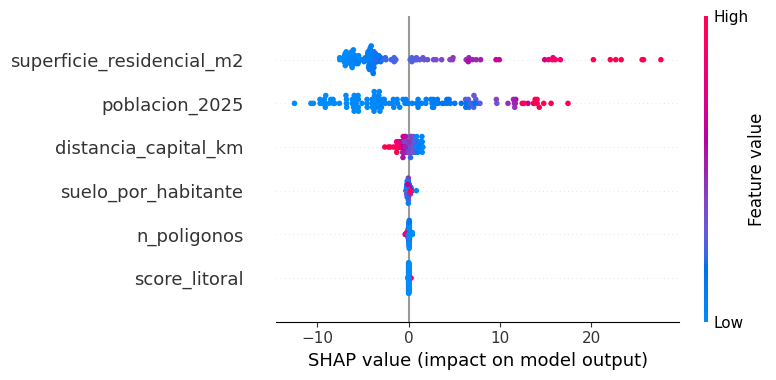

In [20]:
shap.summary_plot(
    shap_values,
    X,
    show=False
)

plt.tight_layout()
plt.show()

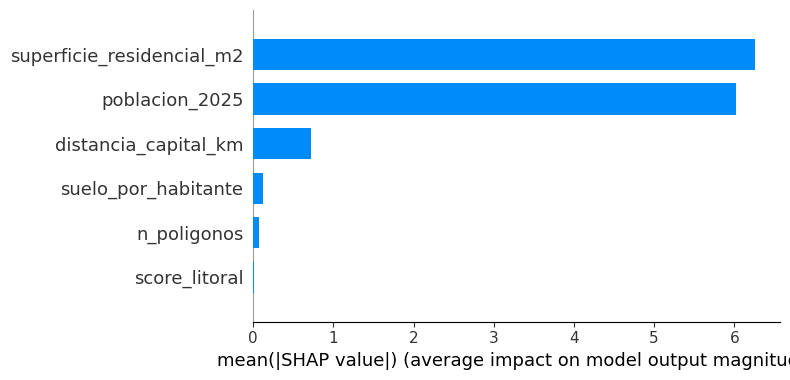

In [21]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

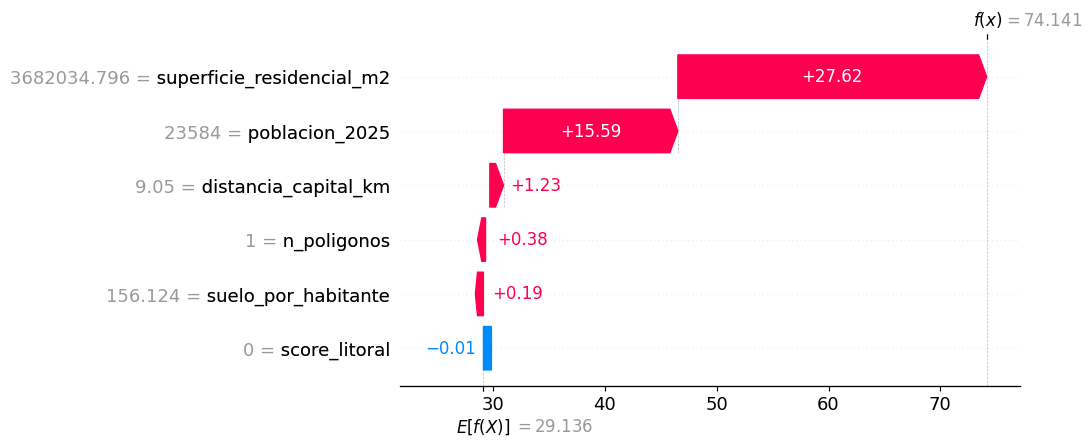

In [22]:
# ==================================================
# SHAP WATERFALL - LAS GABIAS
# ==================================================

idx = df[
    df["municipio"] == "Gabias, Las"
].index[0]

shap.waterfall_plot(

    shap.Explanation(

        values=shap_values[idx],

        base_values=explainer.expected_value,

        data=X.iloc[idx],

        feature_names=features

    )

)

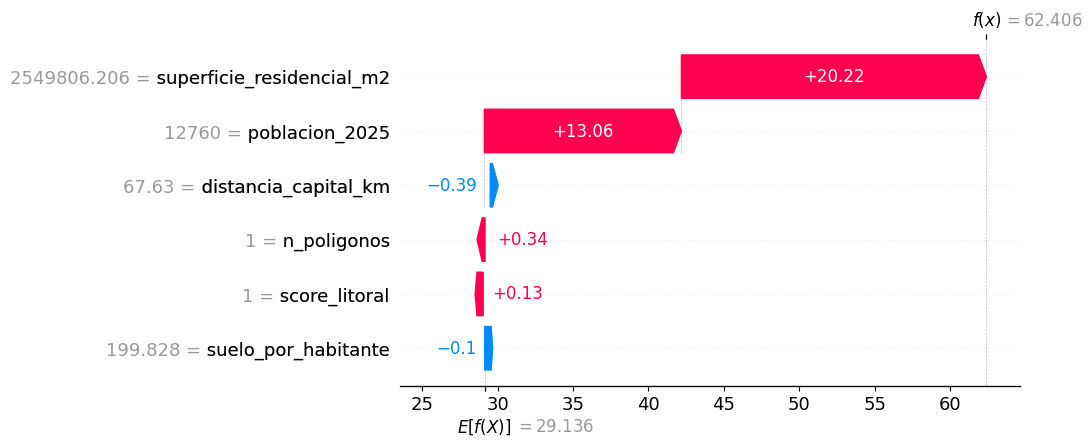

In [23]:
# ==================================================
# SHAP WATERFALL - SALOBREÑA
# ==================================================

idx = df[
    df["municipio"] == "Salobreña"
].index[0]

shap.waterfall_plot(

    shap.Explanation(

        values=shap_values[idx],

        base_values=explainer.expected_value,

        data=X.iloc[idx],

        feature_names=features

    )

)

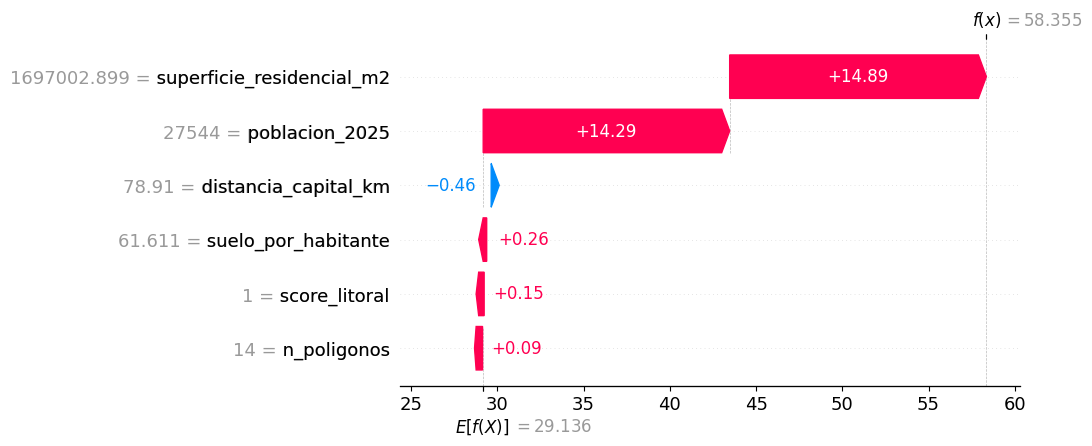

In [24]:
# ==================================================
# SHAP WATERFALL - ALMUÑÉCAR
# ==================================================

idx = df[
    df["municipio"] == "Almuñécar"
].index[0]

shap.waterfall_plot(

    shap.Explanation(

        values=shap_values[idx],

        base_values=explainer.expected_value,

        data=X.iloc[idx],

        feature_names=features

    )

)

In [25]:
# ==================================================
# FUNCIÓN SHAP MUNICIPIO
# ==================================================

def explicar_municipio(nombre_municipio):

    idx = df[
        df["municipio"] == nombre_municipio
    ].index[0]

    print(
        df.loc[
            idx,
            [
                "municipio",
                "coopscore_v6",
                "IVU",
                "IVEC"
            ]
        ]
    )

    shap.waterfall_plot(

        shap.Explanation(

            values=shap_values[idx],

            base_values=explainer.expected_value,

            data=X.iloc[idx],

            feature_names=features

        )

    )